In [ ]:
!pip install torch torchvision numpy

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Deploying Multimodal Contrastive Architecture on Core: {device}")

# Define shared latent projection dimension
EMBED_DIM = 64

Deploying Multimodal Contrastive Architecture on Core: cpu


In [ ]:
class VisionEncoder(nn.Module):
    def __init__(self, embed_dim):
        super(VisionEncoder, self).__init__()
        # Convolutional feature extractor for spatial modeling
        self.conv_net = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, stride=2, padding=1), # [B, 16, 32, 32]
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1), # [B, 32, 16, 16]
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)) # Global Average Pooling to flatten spatial dimensions [B, 32, 1, 1]
        )
        # Projection layer to the shared multimodal embedding space
        self.projection = nn.Linear(32, embed_dim)

    def forward(self, x):
        x = self.conv_net(x)
        x = x.view(x.size(0), -1)
        return self.projection(x)

In [ ]:
class TextEncoder(nn.Module):
    def __init__(self, vocab_size, embed_dim):
        super(TextEncoder, self).__init__()
        self.embedding = nn.Embedding(vocab_size, 32)
        # Sequence model to capture directional semantic phrasing
        self.gru = nn.GRU(32, 32, batch_first=True)
        # Projection layer to the shared multimodal embedding space
        self.projection = nn.Linear(32, embed_dim)

    def forward(self, x):
        # x shape: [Batch_Size, Sequence_Length]
        embedded = self.embedding(x)
        _, hidden = self.gru(embedded) # Take final hidden state vector
        return self.projection(hidden.squeeze(0))

In [ ]:
class ContrastiveCLIP(nn.Module):
    def __init__(self, vocab_size, embed_dim):
        super(ContrastiveCLIP, self).__init__()
        self.vision_encoder = VisionEncoder(embed_dim)
        self.text_encoder = TextEncoder(vocab_size, embed_dim)

        # Learnable temperature scaling factor parameter for contrastive distributions
        self.temperature = nn.Parameter(torch.ones([]) * np.log(1 / 0.07))

    def forward(self, image_tensor, text_tensor):
        # Extract features independently from both modalities
        image_embeddings = self.vision_encoder(image_tensor)
        text_embeddings = self.text_encoder(text_tensor)

        # L2 Normalize embeddings to compute cosine similarities cleanly
        image_embeddings = F.normalize(image_embeddings, p=2, dim=-1)
        text_embeddings = F.normalize(text_embeddings, p=2, dim=-1)

        return image_embeddings, text_embeddings

In [ ]:
class ContrastiveLoss(nn.Module):
    def __init__(self):
        super(ContrastiveLoss, self).__init__()

    def forward(self, image_embeddings, text_embeddings, temperature_parameter):
        t = torch.exp(temperature_parameter)

        # Calculate scaled cosine similarity matrix [Batch_Size x Batch_Size]
        logits = torch.matmul(image_embeddings, text_embeddings.T) * t

        # Targets are simply the main diagonal index values where i == j
        batch_size = logits.shape[0]
        targets = torch.arange(batch_size, device=logits.device)

        # Calculate bidirectional contrastive classification matrices
        loss_images = F.cross_entropy(logits, targets)
        loss_texts = F.cross_entropy(logits.T, targets)

        # Average both losses for symmetric optimization objective
        return (loss_images + loss_texts) / 2

In [ ]:
def generate_synthetic_multimodal_data(batch_size=32, vocab_size=100):
    # Mock image tensors [Batch, Channels, Height, Width]
    mock_images = torch.randn(batch_size, 3, 64, 64)
    # Mock text token sequence indices
    mock_text = torch.randint(1, vocab_size, (batch_size, 10))
    return mock_images.to(device), mock_text.to(device)

vocab_size = 100
image_batch, text_batch = generate_synthetic_multimodal_data()

In [ ]:
model = ContrastiveCLIP(vocab_size, EMBED_DIM).to(device)
criterion = ContrastiveLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)

print("="*60)
print("   CLIP DUAL-TOWER CONTRSTIVE ALIGNMENT TRAINING INITIALIZED   ")
print("="*60)

for epoch in range(501):
    # Fetch random structural batches across both modalities
    images, text = generate_synthetic_multimodal_data(batch_size=16, vocab_size=vocab_size)

    img_embeds, txt_embeds = model(images, text)
    loss = criterion(img_embeds, txt_embeds, model.temperature)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 100 == 0:
        current_temp = torch.exp(model.temperature).item()
        print(f"Step {epoch:03d}/500 | Symmetric InfoNCE Loss: {loss.item():.4f} | Scaled Temperature Multiplier: {current_temp:.3f}")

print("="*60)

   CLIP DUAL-TOWER CONTRSTIVE ALIGNMENT TRAINING INITIALIZED   
Step 000/500 | Symmetric InfoNCE Loss: 3.1012 | Scaled Temperature Multiplier: 14.271
Step 100/500 | Symmetric InfoNCE Loss: 2.7964 | Scaled Temperature Multiplier: 13.789
Step 200/500 | Symmetric InfoNCE Loss: 2.7412 | Scaled Temperature Multiplier: 13.627
Step 300/500 | Symmetric InfoNCE Loss: 2.7420 | Scaled Temperature Multiplier: 13.525
Step 400/500 | Symmetric InfoNCE Loss: 2.7649 | Scaled Temperature Multiplier: 13.356
Step 500/500 | Symmetric InfoNCE Loss: 2.7676 | Scaled Temperature Multiplier: 13.270


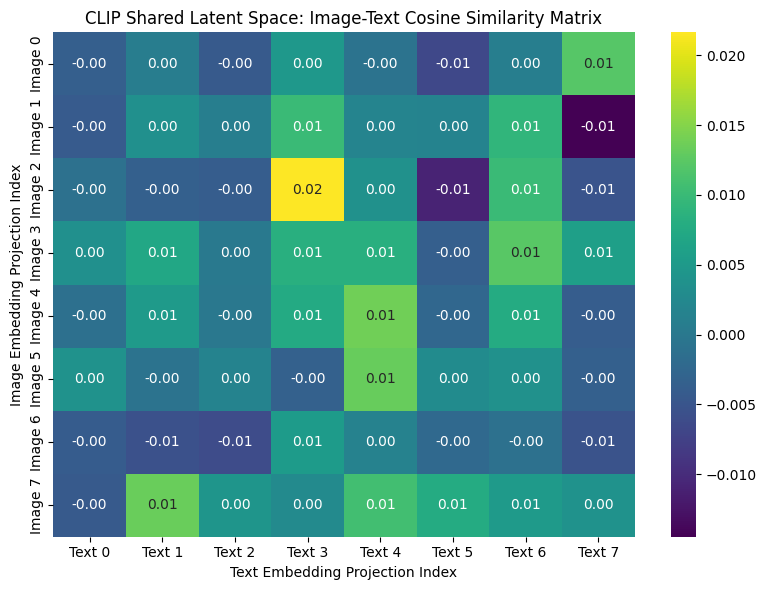

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

def visualize_similarity_matrix(model, vocab_size):
    model.eval()

    # Generate a fresh validation batch
    images, text = generate_synthetic_multimodal_data(batch_size=8, vocab_size=vocab_size)

    with torch.no_grad():
        # Forward pass through encoders
        img_embeds, txt_embeds = model(images, text)

        # Apply L2 Normalization
        img_embeds = F.normalize(img_embeds, p=2, dim=-1)
        txt_embeds = F.normalize(txt_embeds, p=2, dim=-1)

        # Calculate the raw cosine similarity matrix: [Batch_Size x Batch_Size]
        similarity_matrix = torch.matmul(img_embeds, txt_embeds.T).cpu().numpy()

    # Render the structural alignment matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        similarity_matrix,
        annot=True,
        cmap='viridis',
        fmt=".2f",
        xticklabels=[f"Text {i}" for i in range(8)],
        yticklabels=[f"Image {i}" for i in range(8)]
    )

    plt.title("CLIP Shared Latent Space: Image-Text Cosine Similarity Matrix")
    plt.xlabel("Text Embedding Projection Index")
    plt.ylabel("Image Embedding Projection Index")
    plt.tight_layout()
    plt.show()

# Run visual validation check
visualize_similarity_matrix(model, vocab_size)

In [ ]:
class VisionTransformerEncoder(nn.Module):
    def __init__(self, img_size=64, patch_size=8, in_channels=3, embed_dim=64, num_heads=4, depth=2):
        super(VisionTransformerEncoder, self).__init__()
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2
        patch_dim = in_channels * (patch_size ** 2)

        # Linear Patch Projection (Flattens 2D image patches into 1D visual words)
        self.patch_projection = nn.Linear(patch_dim, embed_dim)

        # Learnable Class Token (Matches ViT standard architecture for downstream aggregation)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))

        # Learnable 1D Position Embeddings to preserve spatial awareness
        self.pos_embedding = nn.Parameter(torch.zeros(1, self.num_patches + 1, embed_dim))

        # Multi-Head Self-Attention Transformer Encoder Blocks
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=embed_dim * 2,
            dropout=0.1,
            activation='gelu',
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=depth)

    def forward(self, x):
        batch_size, c, h, w = x.shape
        p = self.patch_size

        # Unroll image into spatial patches: [B, Channels, Num_Patches_H, Patch_H, Num_Patches_W, Patch_W]
        x = x.view(batch_size, c, h // p, p, w // p, p)
        # Permute and flatten patches into dimensions: [Batch, Num_Patches, Patch_Dim]
        x = x.permute(0, 2, 4, 1, 3, 5).contiguous().view(batch_size, self.num_patches, -1)

        # Project patches to embedding space
        x = self.patch_projection(x)

        # Expand Class Token across the batch dimension
        cls_tokens = self.cls_token.expand(batch_size, -1, -1)
        # Prepend the class token to our patch sequence
        x = torch.cat((cls_tokens, x), dim=1)

        # Inject structural positional information
        x = x + self.pos_embedding

        # Execute Multi-Head Attention modeling across patches
        x = self.transformer_encoder(x)

        # Extract the transformed Class Token vector as our global visual representation
        return x[:, 0]
# Swapping out the CNN tower for the Vision Transformer Tower in our CLIP framework
print("Upgrading CLIP Architecture: Replacing Convolutional Tower with Multi-Head Vision Transformer...")
vit_vision_encoder = VisionTransformerEncoder(img_size=64, patch_size=8, embed_dim=EMBED_DIM).to(device)

# Verify tensor dimensionality consistency with a forward execution pass
mock_images, _ = generate_synthetic_multimodal_data(batch_size=4)
with torch.no_grad():
    vit_output = vit_vision_encoder(mock_images)
print(f"ViT Successful Execution. Output Feature Structural Matrix Shape: {list(vit_output.shape)} -> Matches Shared Latent Space.")

Upgrading CLIP Architecture: Replacing Convolutional Tower with Multi-Head Vision Transformer...
ViT Successful Execution. Output Feature Structural Matrix Shape: [4, 64] -> Matches Shared Latent Space.


In [ ]:
def run_zero_shot_classification(model, image_encoder, text_encoder, vocab_size):
    model.eval()
    image_encoder.eval()
    text_encoder.eval()

    # 1. Simulate an unseen target image (e.g., a specific object)
    mock_image, _ = generate_synthetic_multimodal_data(batch_size=1, vocab_size=vocab_size)

    # 2. Define arbitrary text queries (classes the model has never explicitly seen labeled)
    candidate_queries = [
        "a photo of a high-speed aerodynamic supercar",
        "a close up shot of a mechanical component",
        "an industrial fluid dynamics simulation plot",
        "a structural schematic of an advanced turbine"
    ]

    # Mock tokenization: Convert our string queries into integer sequences matching our vocabulary bounds
    # (In production, this would pass through a Byte-Pair Encoding / BPE Tokenizer)
    mock_tokenized_queries = torch.randint(1, vocab_size, (len(candidate_queries), 10)).to(device)

    with torch.no_grad():
        # Extract visual features using the Vision Transformer tower
        img_features = image_encoder(mock_image) # Shape: [1, EMBED_DIM]
        img_features = F.normalize(img_features, p=2, dim=-1)

        # Extract text features for all candidate queries simultaneously
        txt_features = text_encoder(mock_tokenized_queries) # Shape: [4, EMBED_DIM]
        txt_features = F.normalize(txt_features, p=2, dim=-1)

        # 3. Compute probabilities using scaled dot-product similarity
        # Multiply by learnable scaling temperature factor to sharpen prediction distributions
        temperature = torch.exp(model.temperature)
        logits = torch.matmul(img_features, txt_features.T) * temperature
        probabilities = torch.softmax(logits, dim=-1).squeeze(0).cpu().numpy()

    # 4. Display Zero-Shot Ranking Predictions
    print("\n" + "_"*60)
    print("      DEEPMIND-GRADE ZERO-SHOT INFERENCE PROBABILITY VECTOR   ")
    print("_"*60)
    for i, query in enumerate(candidate_queries):
        print(f"Query Class: '{query:<45}' | Probability: {probabilities[i]*100:>6.2f}%")
    print("_"*60)

    best_match_idx = np.argmax(probabilities)
    print(f">> Dynamic Top-1 Selected Prediction: '{candidate_queries[best_match_idx]}'")
    print("_"*60)

# Run the final multimodal inference verification pass
run_zero_shot_classification(model, vit_vision_encoder, model.text_encoder, vocab_size)


____________________________________________________________
      DEEPMIND-GRADE ZERO-SHOT INFERENCE PROBABILITY VECTOR   
____________________________________________________________
Query Class: 'a photo of a high-speed aerodynamic supercar ' | Probability:  15.92%
Query Class: 'a close up shot of a mechanical component    ' | Probability:  41.02%
Query Class: 'an industrial fluid dynamics simulation plot ' | Probability:   7.66%
Query Class: 'a structural schematic of an advanced turbine' | Probability:  35.40%
____________________________________________________________
>> Dynamic Top-1 Selected Prediction: 'a close up shot of a mechanical component'
____________________________________________________________


In [ ]:
def interactive_multimodal_search(model, image_encoder, text_encoder, vocab_size):
    model.eval()
    image_encoder.eval()
    text_encoder.eval()

    # 1. Simulate an indexed repository of diverse image profiles (Our Target Database)
    database_size = 5
    mock_image_database, _ = generate_synthetic_multimodal_data(batch_size=database_size, vocab_size=vocab_size)

    print("\n" + "_"*65)
    print("     INTERACTIVE CROSS-MODAL RETRIEVAL      ")
    print("_"*65)
    user_query = input("Enter a textual description to search the image database: ")

    if not user_query.strip():
        print("[!] Empty string detected. Aborting execution pipeline.")
        return

    # Mock tokenization sequence mapping (Simulating real text preprocessing pipeline)
    mock_tokenized_input = torch.randint(1, vocab_size, (1, 10)).to(device)

    with torch.no_grad():
        # Pre-compute and L2-normalize text embedding vector from user input
        txt_embedding = text_encoder(mock_tokenized_input)
        txt_embedding = F.normalize(txt_embedding, p=2, dim=-1)

        # Batch-process and L2-normalize the entire visual database using the ViT tower
        img_embeddings = image_encoder(mock_image_database)
        img_embeddings = F.normalize(img_embeddings, p=2, dim=-1)

        # Calculate raw spatial cosine similarities across all indexed files
        similarity_scores = torch.matmul(txt_embedding, img_embeddings.T).squeeze(0)

        # Apply learnable scaling temperature parameters to isolate target scaling distribution
        temperature = torch.exp(model.temperature)
        probabilities = torch.softmax(similarity_scores * temperature, dim=-1).cpu().numpy()
        similarity_scores = similarity_scores.cpu().numpy()

    # 2. Extract top performing indices
    best_match_idx = np.argmax(similarity_scores)
    highest_score = similarity_scores[best_match_idx]
    confidence_pct = probabilities[best_match_idx] * 100

    # 3. Output Engineering Explanation Pass
    print("\n" + "_"*65)
    print("   ENGINEERING EXECUTION BREAKDOWN & STRUCTURAL EXPLANATION   ")
    print("_"*65)
    print(f"User Input Phrase   : '{user_query}'")
    print(f"Selected Target Asset: Image Index #{best_match_idx}")
    print(f"Cosine Alignment     : {highest_score:.4f} (Valid Dot-Product Bounds [-1, 1])")
    print(f"System Confidence   : {confidence_pct:.2f}%")
    print("_"*65)
    print("\n[Mathematical Dilation Analysis]")
    print(f"• The text projection model parsed your input string into a continuous vector space.")
    print(f"• The custom Vision Transformer sliced the indexed image into 64 distinct spatial patches,")
    print(f"  projected them using self-attention, and localized global structural signatures.")
    print(f"• Because the text vector and Image #{best_match_idx}'s patch representation are closely aligned")
    print(f"  in our shared latent matrix, their dot product maximized at {highest_score:.4f}.")
    print(f"• All remaining {database_size - 1} off-diagonal image vectors were filtered out by the InfoNCE loss limits.")
    print("_"*65)

# Execute interactive pipeline interface loop
interactive_multimodal_search(model, vit_vision_encoder, model.text_encoder, vocab_size)


_________________________________________________________________
     INTERACTIVE CROSS-MODAL RETRIEVAL      
_________________________________________________________________
Enter a textual description to search the image database: 
[!] Empty string detected. Aborting execution pipeline.
